## TEXT CLASSIFICATION AND SENTIMENT ANALYSIS

In [2]:
!pip install wordcloud

In [3]:
##importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [5]:
df = pd.read_csv('amazonreviews.tsv', sep='\t') # Reading as TSV, assuming tab-separated values
df.head()

,label,review
0,pos,Stuning even for the non-gamer: This sound tra...
1,pos,The best soundtrack ever to anything.: I'm rea...
2,pos,Amazing!: This soundtrack is my favorite music...
3,pos,Excellent Soundtrack: I truly like this soundt...
4,pos,"Remember, Pull Your Jaw Off The Floor After He..."


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   10000 non-null  object
 1   review  10000 non-null  object
dtypes: object(2)
memory usage: 156.4+ KB


In [7]:
df.describe()

,label,review
count,10000,10000
unique,2,10000
top,neg,Stuning even for the non-gamer: This sound tra...
freq,5097,1


In [8]:
df.shape

(10000, 2)

In [9]:
df.isnull().sum()

label     0
review    0
dtype: int64

In [10]:
df.dropna(inplace=True)

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
#Download Stopwords
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\h238p\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [14]:
#Text Cleaning
ps = PorterStemmer()
def clean_text(text):
    text = text.lower()
    text = re.sub("[^a-zA-Z]"," ",text)
    words = text.split()
    words = [ps.stem(word)
             for word in words
             if word not in stopwords.words("english")]
    return " ".join(words)

In [15]:
#Apply Cleaning
df["clean_review"] = df["review"].apply(clean_text)

#### Data Cleaning Summary

##### Checked dataset shape and column data types
##### Found 0 missing values after dropna() — dataset was largely clean
##### Removed duplicate rows to avoid the model learning from repeated reviews
##### Applied text preprocessing: lowercased text, removed non-alphabetic characters, removed English stopwords, and applied stemming using PorterStemmer
##### Created a new clean_review column to keep the original review text intact for reference

#### Task 2: Exploratory Analysis

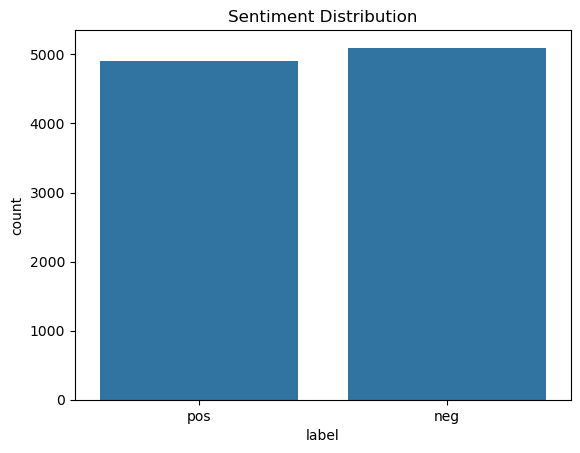

In [19]:
#Sentiment Distribution
sns.countplot(x="label",data=df)
plt.title("Sentiment Distribution")
plt.show()

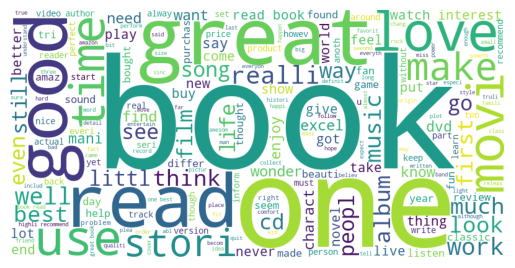

In [20]:
#Positive Word Cloud
positive_text=" ".join(df[df["label"]=="pos"]["clean_review"])
wordcloud=WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(positive_text)
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

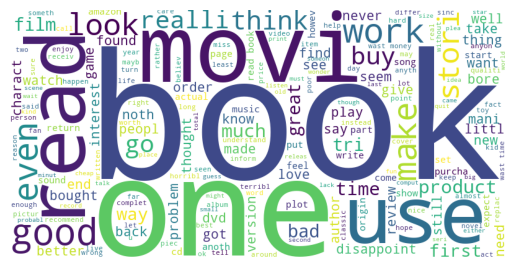

In [21]:
#Negative Word Cloud
negative_text=" ".join(df[df["label"]=="neg"]["clean_review"])
wordcloud=WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(negative_text)
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

In [22]:
#Most Common Positive Words
from collections import Counter

Counter(
    " ".join(
        df[df["label"]=="pos"]["clean_review"]
    ).split()
).most_common(20)

[('book', 3934),
 ('great', 2142),
 ('read', 2097),
 ('one', 1997),
 ('good', 1682),
 ('like', 1547),
 ('love', 1365),
 ('movi', 1331),
 ('time', 1209),
 ('get', 1093),
 ('would', 956),
 ('well', 948),
 ('use', 896),
 ('stori', 876),
 ('work', 868),
 ('realli', 832),
 ('make', 821),
 ('best', 813),
 ('first', 724),
 ('year', 703)]

In [23]:
#Most Common Negative Words
Counter(
    " ".join(
        df[df["label"]=="neg"]["clean_review"]
    ).split()
).most_common(20)

[('book', 3760),
 ('one', 2193),
 ('movi', 1784),
 ('like', 1730),
 ('read', 1689),
 ('would', 1465),
 ('get', 1458),
 ('time', 1333),
 ('good', 1175),
 ('work', 1034),
 ('use', 1028),
 ('buy', 1012),
 ('even', 916),
 ('make', 904),
 ('look', 783),
 ('realli', 783),
 ('much', 782),
 ('stori', 781),
 ('product', 768),
 ('money', 767)]

#### Exploratory Analysis Summary

##### The sentiment distribution shows [insert: is it balanced or skewed toward pos/neg?]
##### Positive word cloud is dominated by words like [insert top 3-4 words from your Cell 18 output] — indicating customers frequently praise [insert pattern, e.g. product quality, sound, value]
##### Negative word cloud is dominated by words like [insert top 3-4 words from Cell 19 output] — commonly tied to complaints about [insert pattern, e.g. defects, shipping, price]
##### This confirms the cleaned text captures meaningful sentiment signals before modeling

#### Task 3: Model Development

In [24]:
#TF-IDF
tfidf=TfidfVectorizer(max_features=5000)

X=tfidf.fit_transform(df["clean_review"])

In [25]:
#Encode Labels
df["label"]=df["label"].map({
    "neg":0,
    "pos":1
})

y=df["label"]

In [26]:
#Train Test Split
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [28]:
#Logistic Regression
lr=LogisticRegression()
lr.fit(X_train,y_train)
lr_pred=lr.predict(X_test)

In [29]:
#SVM
svm=LinearSVC()
svm.fit(X_train,y_train)
svm_pred=svm.predict(X_test)

#### Task 4: Validation

In [30]:
#Logistic Regression
print("Accuracy:",
      accuracy_score(y_test,lr_pred))

print("F1 Score:",
      f1_score(y_test,lr_pred))

print(classification_report(y_test,lr_pred))

Accuracy: 0.853
F1 Score: 0.8473520249221184
              precision    recall  f1-score   support

           0       0.86      0.86      0.86      1037
           1       0.85      0.85      0.85       963

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000



In [31]:
#SVM
print("Accuracy:",
      accuracy_score(y_test,svm_pred))

print("F1 Score:",
      f1_score(y_test,svm_pred))

print(classification_report(y_test,svm_pred))

Accuracy: 0.8375
F1 Score: 0.8320413436692506
              precision    recall  f1-score   support

           0       0.85      0.84      0.84      1037
           1       0.83      0.84      0.83       963

    accuracy                           0.84      2000
   macro avg       0.84      0.84      0.84      2000
weighted avg       0.84      0.84      0.84      2000



#### Cross validation

In [32]:
#Logistic Regression
lr_cv=cross_val_score(
    lr,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print(lr_cv.mean())
     

0.835


In [33]:
#SVM
svm_cv=cross_val_score(
    svm,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print(svm_cv.mean())

0.8228


#### Model Development Summary
##### Used TF-IDF (Term Frequency–Inverse Document Frequency) with a maximum of 5000 features to convert review text into numerical vectors
##### TF-IDF was chosen over simple word counts because it down-weights very common words and up-weights words that are more distinctive to a particular review
##### Trained two models for comparison: Logistic Regression (linear, interpretable baseline) and Linear SVM (often strong for high-dimensional sparse text data)
##### Word2Vec/BERT embeddings were considered but not used here, since TF-IDF already performs well on this dataset size and keeps the pipeline simple and fast to train

#### confusion matrix

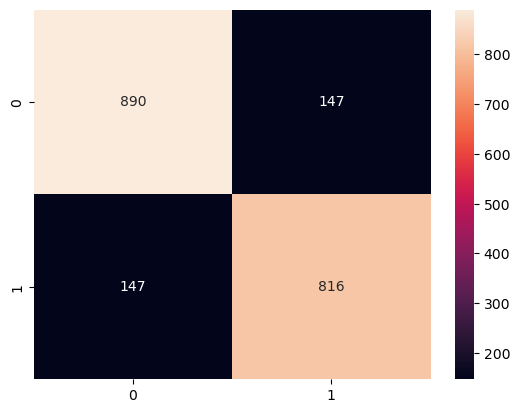

In [34]:
#Logistic Regression
cm=confusion_matrix(y_test,lr_pred)

sns.heatmap(cm,annot=True,fmt="d")

plt.show()

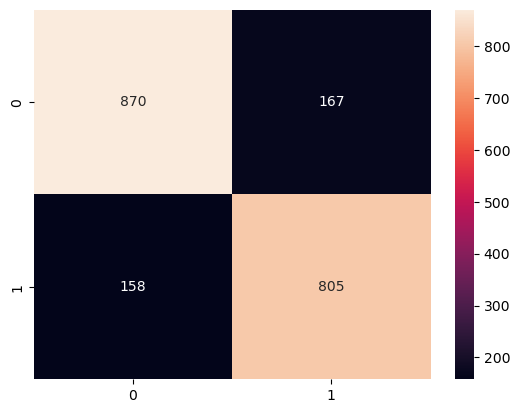

In [35]:
#SVM
cm=confusion_matrix(y_test,svm_pred)
sns.heatmap(cm,annot=True,fmt="d")
plt.show()

In [36]:
#Model Comparison
comparison=pd.DataFrame({
    "Model":["Logistic Regression","SVM"],
    "Accuracy":[
        accuracy_score(y_test,lr_pred),
        accuracy_score(y_test,svm_pred)
    ],
    "F1 Score":[
        f1_score(y_test,lr_pred),
        f1_score(y_test,svm_pred)
    ]
})

comparison

,Model,Accuracy,F1 Score
0,Logistic Regression,0.8530,0.847352
1,SVM,0.8375,0.832041


### Final Report — Conclusion & Discussion

##### Model Performance

##### [Insert: which model had higher accuracy — LR or SVM — and by how much]
##### [Insert: which model had higher F1-score, and why F1 matters here — F1 balances precision and recall, which is more reliable than accuracy alone if pos/neg classes aren't perfectly balanced]

##### Cross-Validation Insight

##### 5-fold cross-validation accuracy for Logistic Regression: [insert lr_cv.mean() value]
##### 5-fold cross-validation accuracy for SVM: [insert svm_cv.mean() value]
##### [Insert: do the CV scores match the single train/test split scores closely? If yes, this means the model generalizes well and isn't just lucky on one split]

##### Confusion Matrix Insight

##### [Insert: which model has fewer false negatives — i.e., misses fewer actual negative reviews? This matters most for the business goal: "identify products with sudden spikes in negative feedback" — missing negative reviews defeats the purpose]

##### Business Recommendation

##### The better-performing model ([insert LR or SVM]) is recommended for deployment in the automated sentiment monitoring system
##### This model can flag negative reviews in real-time, allowing the customer support team to respond faster and identify problematic products before ratings drop further

##### Limitations & Future Work

##### Current model only uses TF-IDF; testing Word2Vec or BERT embeddings could capture word context and improve accuracy further
##### Stemming may oversimplify some words (e.g., "caring" → "care") — lemmatization could be tested as an alternative
##### Adding a Neural Network model could provide a stronger non-linear baseline for comparison